# Load test results: latency vs concurrency and slot count

Analyses the `slots.N.csv` files produced by `tests/load_test.py`.

Two plots:
1. **Latency vs concurrency**: mean ± SEM and p95, one line per slot count.
2. **Latency at concurrency = 8 vs slot count**: mean ± SEM and p95.

In [1]:
'''Plots load test results.'''

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
})

RESULTS_DIR = Path('..') / 'tests' / 'results'
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

In [2]:
# ---------------------------------------------------------------------------
# Load all slots.N.csv files present in the results directory
# ---------------------------------------------------------------------------
slot_files = sorted(
    RESULTS_DIR.glob('slots.*.csv'),
    key=lambda p: int(re.search(r'slots\.(\d+)\.csv', p.name).group(1)),
)

if not slot_files:
    raise FileNotFoundError(f'No slots.*.csv files found in {RESULTS_DIR.resolve()}')

frames = []
for path in slot_files:
    df = pd.read_csv(path)
    frames.append(df)

raw = pd.concat(frames, ignore_index=True)

# Keep only successful rows; pd.read_csv converts the string 'NaN' in the
# error column to a real NaN, so filter with isna() rather than == 'NaN'.
data = raw[raw['error'].isna()].copy()
data['slots'] = data['slots'].astype(int)
data['concurrency'] = data['concurrency'].astype(int)
data['latency_s'] = data['latency_s'].astype(float)

slot_counts = sorted(data['slots'].unique())
print(f'Slot counts found: {slot_counts}')
print(f'Concurrency levels: {sorted(data["concurrency"].unique())}')
print(f'Total successful rows: {len(data)}')

Slot counts found: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32)]
Concurrency levels: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32)]
Total successful rows: 1133


In [ ]:

# ---------------------------------------------------------------------------
# Helper: compute mean, SEM, p95 grouped by specified columns
# ---------------------------------------------------------------------------
def summarize(results, group_cols):
    """Compute mean, SEM, and p95 latency for each group.

    Parameters
    ----------
    results : pd.DataFrame
        Filtered rows of raw load-test data (errors already removed).
    group_cols : list[str]
        Column names to group by (e.g. ['slots', 'concurrency']).

    Returns
    -------
    pd.DataFrame
        One row per group with columns: mean, count, std, p95, sem.
    """

    agg = (
        results.groupby(group_cols)['latency_s']
        .agg(
            mean='mean',
            count='count',
            std='std',
            p95=lambda x: x.quantile(0.95),
        )
        .reset_index()
    )
    agg['sem'] = agg['std'] / np.sqrt(agg['count'])

    return agg


## Plot 1: latency vs concurrency, by slot count

Each slot count gets a pair of traces: solid line for mean ± SEM, dotted line with diamond markers for p95.

Saved figures/latency_vs_concurrency.png


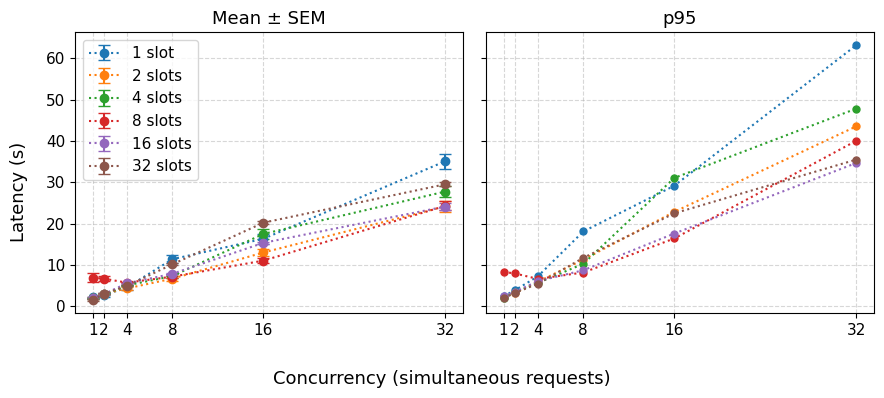

In [4]:
stats_by_slots = summarize(data, ['slots', 'concurrency'])

cmap = plt.get_cmap('tab10')
colors = [cmap(i) for i in range(len(slot_counts))]
all_concurrencies = sorted(data['concurrency'].unique())

fig1, (ax_mean, ax_p95) = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

for i, n_slots in enumerate(slot_counts):
    subset = stats_by_slots[stats_by_slots['slots'] == n_slots].sort_values('concurrency')
    color = colors[i]
    label = f'{n_slots} slot{"s" if n_slots > 1 else ""}'

    # Mean ± SEM, left panel
    ax_mean.errorbar(
        subset['concurrency'], subset['mean'],
        yerr=subset['sem'],
        marker='o', markersize=6, linewidth=1.5, linestyle=':',
        capsize=4, color=color, label=label,
    )

    # p95, right panel
    ax_p95.plot(
        subset['concurrency'], subset['p95'],
        marker='o', markersize=5, linewidth=1.5, linestyle=':',
        color=color, label=label,
    )

for ax, title in [(ax_mean, 'Mean ± SEM'), (ax_p95, 'p95')]:
    ax.set_title(title)
    ax.set_xticks(all_concurrencies)
    ax.grid(True, linestyle='--', alpha=0.5)

ax_mean.legend()
fig1.supxlabel('Concurrency (simultaneous requests)', fontsize=13)
fig1.supylabel('Latency (s)', fontsize=13)
fig1.tight_layout()

out1 = FIGURES_DIR / 'latency_vs_concurrency.png'
fig1.savefig(out1, dpi=150, bbox_inches='tight')
print(f'Saved {out1}')
plt.show()


## Plot 2: latency at concurrency = 8 vs slot count

Shows how increasing the number of server slots affects latency when 8 requests arrive simultaneously.

Saved figures/latency_vs_slots_c8.png


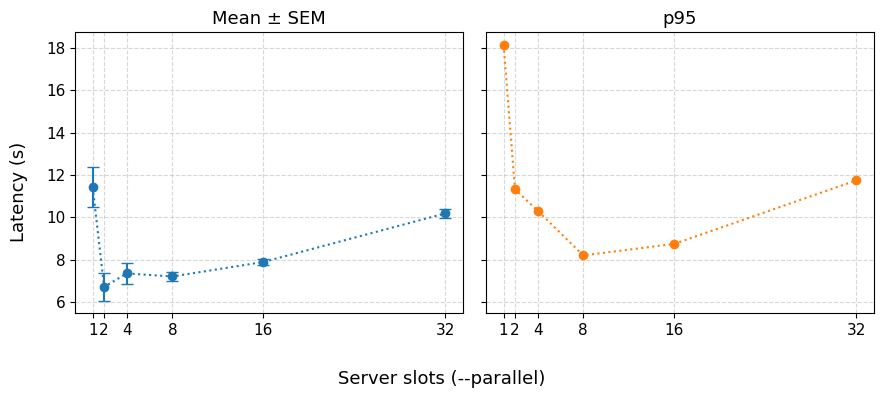

In [5]:
TARGET_CONCURRENCY = 8

data_c8 = data[data['concurrency'] == TARGET_CONCURRENCY]

if data_c8.empty:
    print(f'No data for concurrency={TARGET_CONCURRENCY}. Adjust TARGET_CONCURRENCY above.')
else:
    stats_c8 = summarize(data_c8, ['slots'])

    tab10 = plt.get_cmap('tab10')

    fig2, (ax_mean, ax_p95) = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

    # Mean ± SEM, left panel
    ax_mean.errorbar(
        stats_c8['slots'], stats_c8['mean'],
        yerr=stats_c8['sem'],
        marker='o', markersize=6, linewidth=1.5, linestyle=':',
        capsize=4, color=tab10(0),
    )
    ax_mean.set_title('Mean ± SEM')

    # p95, right panel
    ax_p95.plot(
        stats_c8['slots'], stats_c8['p95'],
        marker='o', markersize=6, linewidth=1.5, linestyle=':',
        color=tab10(1),
    )
    ax_p95.set_title('p95')

    for ax in (ax_mean, ax_p95):
        ax.set_xticks(stats_c8['slots'].tolist())
        ax.grid(True, linestyle='--', alpha=0.5)

    fig2.supxlabel('Server slots (--parallel)', fontsize=13)
    fig2.supylabel('Latency (s)', fontsize=13)
    fig2.tight_layout()

    out2 = FIGURES_DIR / f'latency_vs_slots_c{TARGET_CONCURRENCY}.png'
    fig2.savefig(out2, dpi=150, bbox_inches='tight')
    print(f'Saved {out2}')
    plt.show()


## Plot 3: context length per slot

The server is configured with `-c 65536` total context tokens, shared equally across all slots (`--parallel`).
More slots means less context available per individual request.


Saved figures/context_per_slot.png


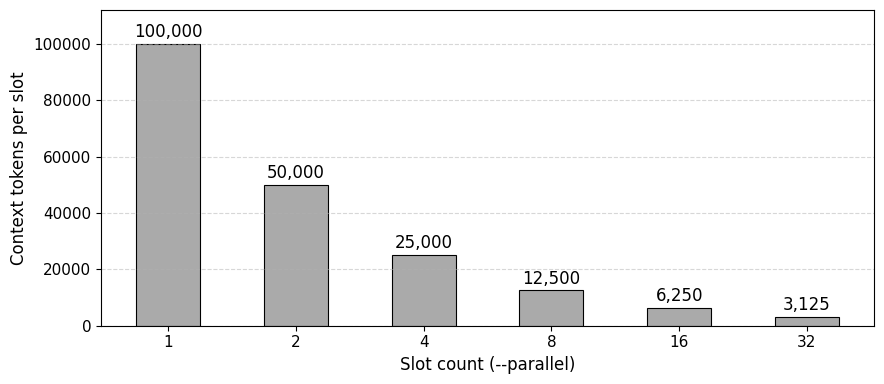

In [2]:
TOTAL_CONTEXT = 100000
slots = [1, 2, 4, 8, 16, 32]
ctx_per_slot = [TOTAL_CONTEXT // s for s in slots]

fig3, ax = plt.subplots(figsize=(9, 4))

ax.bar(
    [str(s) for s in slots],
    ctx_per_slot,
    color='#aaaaaa', edgecolor='black', linewidth=0.8, width=0.5,
)

for s, ctx in zip(slots, ctx_per_slot):
    ax.text(
        str(s), ctx + TOTAL_CONTEXT * 0.01,
        f'{ctx:,}', ha='center', va='bottom', fontsize=12,
    )

ax.set_xlabel('Slot count (--parallel)')
ax.set_ylabel('Context tokens per slot')
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_ylim(0, TOTAL_CONTEXT * 1.12)
fig3.tight_layout()

out3 = FIGURES_DIR / 'context_per_slot.png'
fig3.savefig(out3, dpi=150, bbox_inches='tight')
print(f'Saved {out3}')
plt.show()